
# Lab 6: FEM 1D

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

In [1]:
#Librerias
import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate

## Formulación FEM

Con funciones lineales en cada elemento, la matriz local y el vector local son

$$K^e=\frac{1}{h}\begin{bmatrix}1&-1\\-1&1\end{bmatrix},$$

$$F^e_i=\int_{x_e}^{x_{e+1}} f(x)N_i(x)\,dx.$$

In [2]:
def fem_1D(f, a, b, ua, ub, N):
    nodes = np.linspace(a, b, N + 1)
    h = (b - a) / N

    A = np.zeros((N + 1, N + 1))
    rhs = np.zeros(N + 1)

    for e in range(N):
        x1, x2 = nodes[e], nodes[e + 1]

        Ke = (1 / h) * np.array([[1, -1], [-1, 1]])

        N1 = lambda x: (x2 - x) / h
        N2 = lambda x: (x - x1) / h

        Fe = np.array([
            integrate.quad(lambda x: f(x) * N1(x), x1, x2)[0],
            integrate.quad(lambda x: f(x) * N2(x), x1, x2)[0]
        ])

        idx = [e, e + 1]
        A[np.ix_(idx, idx)] += Ke
        rhs[idx] += Fe

    rhs -= A[:, 0] * ua
    rhs -= A[:, -1] * ub

    A[0, :] = 0
    A[:, 0] = 0
    A[-1, :] = 0
    A[:, -1] = 0
    A[0, 0] = 1
    A[-1, -1] = 1
    rhs[0] = ua
    rhs[-1] = ub

    sol = np.linalg.solve(A, rhs)
    return nodes, sol


## Aplicación al problema

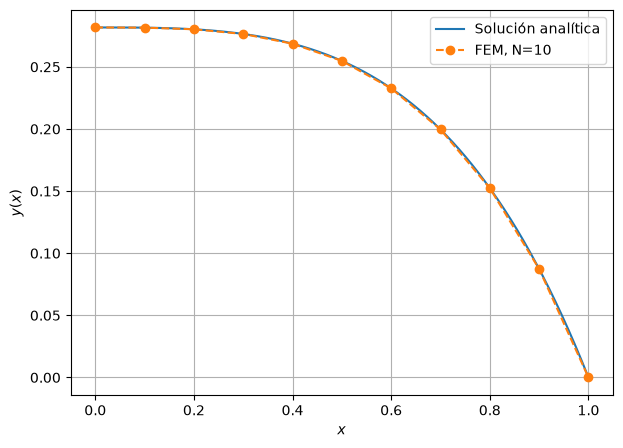

In [3]:
f = lambda x: x * np.exp(x)
exact = lambda x: 1 - np.e - np.exp(x) * (x - 2) - x

a, b = 0.0, 1.0
ua, ub = 3.0 - np.e, 0.0
N = 10

nodes, sol = fem_1D(f, a, b, ua, ub, N)

x_fine = np.linspace(a, b, 1000)
y_exact = exact(x_fine)
y_fem = np.interp(x_fine, nodes, sol)

plt.figure(figsize=(7, 5))
plt.plot(x_fine, y_exact, label='Solución analítica')
plt.plot(nodes, sol, 'o--', label=f'FEM, N={N}')
plt.xlabel('$x$')
plt.ylabel('$y(x)$')
plt.grid(True)
plt.legend()
plt.show()


## Comparación para diferentes números de elementos

El error se calcula sobre una malla fina usando la interpolación lineal de la solución FEM.

In [4]:
Ns = [4, 8, 16, 32, 64]
x_fine = np.linspace(a, b, 5000)
errors = []

for N in Ns:
    nodes, sol = fem_1D(f, a, b, ua, ub, N)
    y_fem = np.interp(x_fine, nodes, sol)
    error = np.max(np.abs(exact(x_fine) - y_fem))
    errors.append(error)

print('N       h             error L_inf')
for N, error in zip(Ns, errors):
    print(f'{N:<7} {1/N:<13.6f} {error:.6e}')


N       h             error L_inf
4       0.250000      1.650144e-02
8       0.125000      4.682695e-03
16      0.062500      1.246689e-03
32      0.031250      3.215967e-04
64      0.015625      8.166846e-05


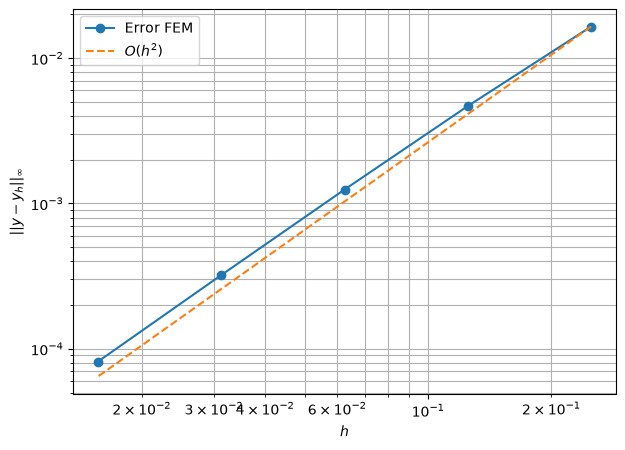

In [5]:
plt.figure(figsize=(7, 5))
plt.loglog([1/N for N in Ns], errors, 'o-', label='Error FEM')
plt.loglog([1/N for N in Ns], [errors[0] * (1/N / (1/Ns[0]))**2 for N in Ns], '--', label='$O(h^2)$')
plt.xlabel('$h$')
plt.ylabel('$||y-y_h||_\\infty$')
plt.grid(True, which='both')
plt.legend()
plt.show()


## Conclusión

La solución FEM se acerca a la solución analítica al aumentar el número de elementos. La función `fem_1D` es general para problemas de la forma $-y''=f(x)$ con condiciones de Dirichlet en los extremos.